# Bölüm 2: Python ile Sayısal MLE

In [16]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
# Gözlemlenen Trafik Verisi (1 dakikada geçen araç sayısı)
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])
def negative_log_likelihood(lam, data):

 n = len(data)
 nll = (n * lam) - (np.log(lam) * np.sum(data))
 return nll
# Başlangıç tahmini
initial_guess = 1.0

# Optimizasyon: NLL'yi minimize etmek, Likelihood'u maximize etmektir.
result = opt.minimize(negative_log_likelihood,
initial_guess, args=(traffic_data,), bounds=[(0.001, None)])
print(f"Sayısal Tahmin (MLE lambda): {result.x[0]}")
print(f"Analitik Tahmin (Ortalama): {np.mean(traffic_data)}")

Sayısal Tahmin (MLE lambda): 12.142853265525986
Analitik Tahmin (Ortalama): 12.142857142857142


# Bölüm 3: Model Karşılaştırma ve Görselleştirme

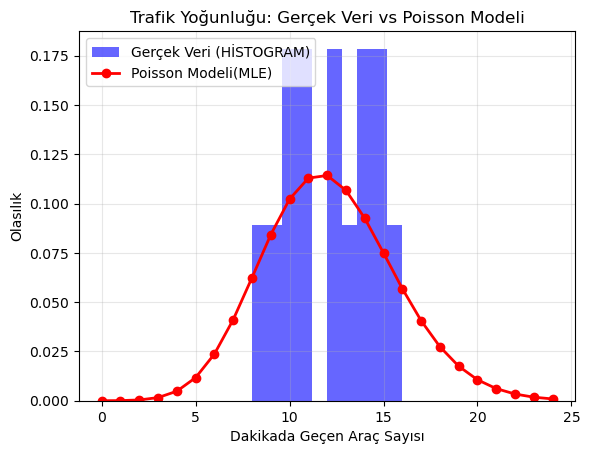

In [ ]:
from scipy.stats import poisson
import numpy as np
import matplotlib.pyplot as plt
#0dan 25 kadar (25 dahil değil) tam sayı dizisi
x_degerleri = np.arange(0, 25)

pmf_degerleri = poisson.pmf( k=x_degerleri  , mu=np.mean(traffic_data))

#1. gerçek veri(histogram)
plt.hist(traffic_data, bins=10, density=True, alpha=0.6, color='blue', label='Gerçek Veri (HİSTOGRAM)')

#2.model

plt.plot(x_degerleri, pmf_degerleri, 'ro-', linewidth=2, label='Poisson Modeli(MLE)')


plt.title("Trafik Yoğunluğu: Gerçek Veri vs Poisson Modeli") # Başlık
plt.xlabel("Dakikada Geçen Araç Sayısı") # X ekseni etiketi
plt.ylabel("Olasılık") # Y ekseni etiketi
plt.legend() # Etiketleri (label) grafikte gösteren kutucuk
plt.grid(True, alpha=0.3) # Okumayı kolaylaştıran arka plan ızgarası

plt.show() # Grafiği ekrana bas